### Purpose of the analysis: **Comparison of selected classification algorithms on the Pima Indians dataset for diabetes diagnosis.**

### Description of the analyzed dataset: **The Pima Indians Diabetes dataset contains medical information for women from the Pima Indian population. Its purpose is to predict the occurrence of diabetes based on features such as the number of pregnancies, plasma glucose concentration, blood pressure, skinfold thickness, insulin level, BMI, diabetes pedigree function, and age. The classification result (the target variable) indicates whether the patient has diabetes (1) or not (0).**

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!wget bigbang.prz.edu.pl/si-inz/pima_indians.csv

--2025-01-30 14:11:46--  http://bigbang.prz.edu.pl/si-inz/pima_indians.csv
Resolving bigbang.prz.edu.pl (bigbang.prz.edu.pl)... 89.188.209.177
Connecting to bigbang.prz.edu.pl (bigbang.prz.edu.pl)|89.188.209.177|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://bigbang.prz.edu.pl/si-inz/pima_indians.csv [following]
--2025-01-30 14:11:46--  https://bigbang.prz.edu.pl/si-inz/pima_indians.csv
Connecting to bigbang.prz.edu.pl (bigbang.prz.edu.pl)|89.188.209.177|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24404 (24K) [text/csv]
Saving to: ‘pima_indians.csv.2’

pima_indians.csv.2  100%[===================>]  23.83K  --.-KB/s    in 0.1s    

2025-01-30 14:11:47 (160 KB/s) - ‘pima_indians.csv.2’ saved [24404/24404]



In [ ]:
!ls -l

total 76
-rw-r--r-- 1 root root 24404 Nov 23  2022 pima_indians.csv
-rw-r--r-- 1 root root 24404 Nov 23  2022 pima_indians.csv.1
-rw-r--r-- 1 root root 24404 Nov 23  2022 pima_indians.csv.2
drwxr-xr-x 1 root root  4096 Jan 28 14:22 sample_data


In [ ]:
column_names = ['Pregnancies',	'Glucose', 'BloodPressure',	'SkinThickness',	'Insulin',	'BMI',	'DiabetesPedigreeFunction',	'Age',	'Outcome']
data = pd.read_csv("pima_indians.csv", header=9, names = column_names)
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,85,66,29,0,26.6,0.351,31,0
1,8,183,64,0,0,23.3,0.672,32,1
2,1,89,66,23,94,28.1,0.167,21,0
3,0,137,40,35,168,43.1,2.288,33,1
4,5,116,74,0,0,25.6,0.201,30,0
...,...,...,...,...,...,...,...,...,...
762,10,101,76,48,180,32.9,0.171,63,0
763,2,122,70,27,0,36.8,0.340,27,0
764,5,121,72,23,112,26.2,0.245,30,0
765,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
len(data[data['Outcome'] == 0])

500

In [ ]:
len(data[data['Outcome'] == 1])

267

In [ ]:
columns_with_0 = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
(data[columns_with_0] == 0).sum()

,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,373
BMI,11


In [ ]:
data[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] = data[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']].replace(0,np.NaN)

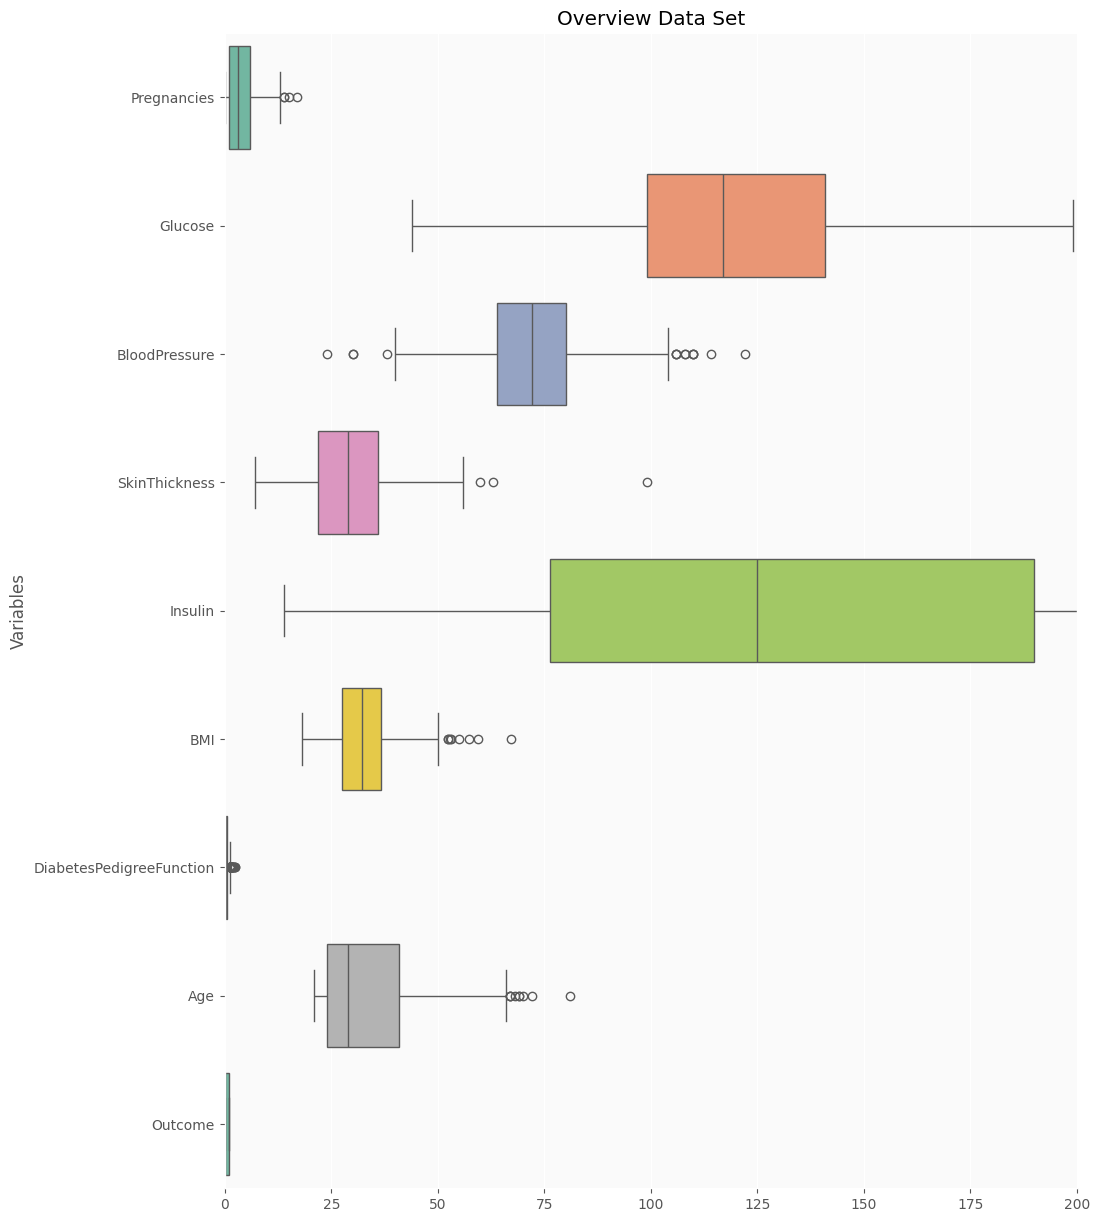

In [ ]:
plt.style.use('ggplot')

f, ax = plt.subplots(figsize=(11, 15))

ax.set_facecolor('#fafafa')
ax.set(xlim=(-.05, 200))
plt.ylabel('Variables')
plt.title("Overview Data Set")
ax = sns.boxplot(data = data,
  orient = 'h',
  palette = 'Set2')

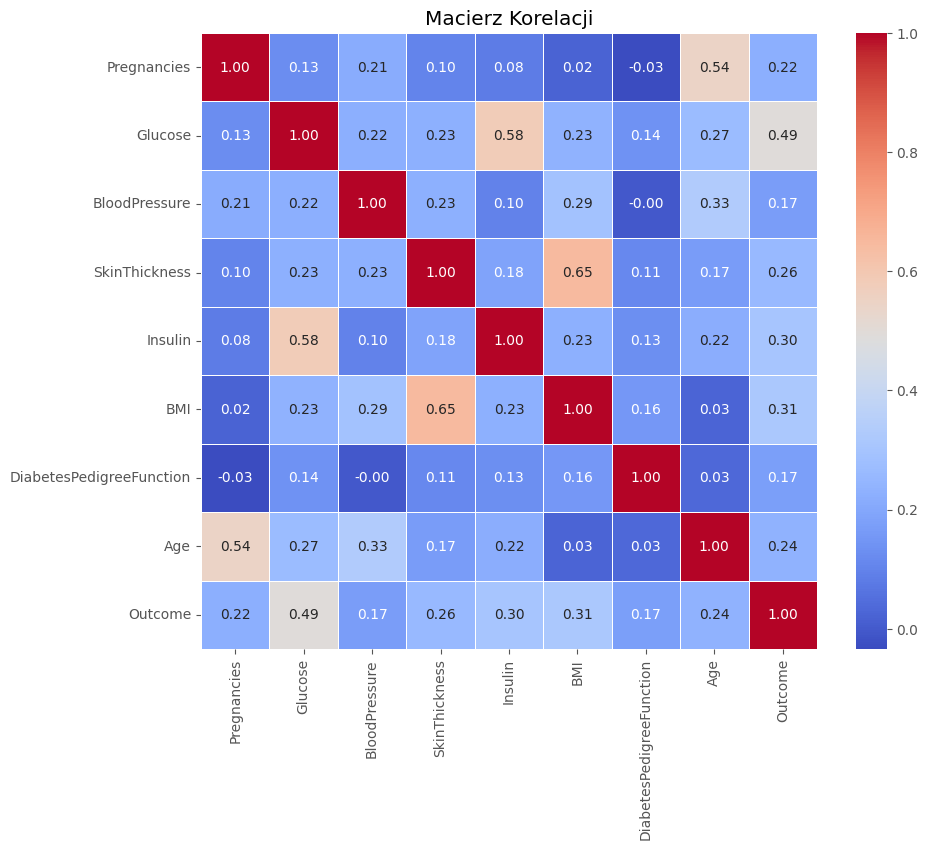

In [ ]:
corr_matrix = data.corr()

plt.figure(figsize=(10, 8))
heatmap = sns.heatmap(corr_matrix,
                      annot=True,
                      fmt=".2f",
                      cmap="coolwarm",
                      linewidths=.5,
                      square=True)

plt.title('Macierz Korelacji')
plt.show()

In [ ]:
def median_for_outcomes(column):
    # Obliczenie mediany dla Outcome == 0
    median_0 = np.nanmedian(data.loc[data['Outcome'] == 0, column])
    # Obliczenie mediany dla Outcome == 1
    median_1 = np.nanmedian(data.loc[data['Outcome'] == 1, column])

    print(f'Median_0 for column {column} is {median_0} and median_1 is {median_1}')

    data.loc[(data['Outcome'] == 0 ) & (data[column].isnull()), column] = median_0
    data.loc[(data['Outcome'] == 1 ) & (data[column].isnull()), column] = median_1

In [ ]:
for column in columns_with_0:
  median_for_outcomes(column)

Median_0 for column Glucose is 107.0 and median_1 is 140.0
Median_0 for column BloodPressure is 70.0 and median_1 is 75.0
Median_0 for column SkinThickness is 27.0 and median_1 is 32.0
Median_0 for column Insulin is 102.5 and median_1 is 169.5
Median_0 for column BMI is 30.1 and median_1 is 34.3


In [ ]:
np.sum(data.isnull())

/usr/local/lib/python3.11/dist-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
X = data.drop('Outcome', axis=1)
y = data['Outcome']

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score
from tabulate import tabulate
from scipy.stats import randint, uniform
import lightgbm as lgbm
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, train_test_split, cross_val_score, StratifiedKFold
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import numpy as np

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

healthy_test = X_test[y_test == 0]
diabetic_test = X_test[y_test == 1]

min_test_size = min(len(healthy_test), len(diabetic_test))

healthy_test_balanced = resample(healthy_test, replace=False, n_samples=min_test_size, random_state=42)
diabetic_test_balanced = resample(diabetic_test, replace=False, n_samples=min_test_size, random_state=42)

X_test_balanced = pd.concat([healthy_test_balanced, diabetic_test_balanced])
y_test_balanced = np.concatenate([np.zeros(min_test_size), np.ones(min_test_size)])

In [ ]:
print(len(X_train))
print(len(X_test_balanced))


613
114


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test_balanced)

# LightGBM Model

In [ ]:
param_test_lgbm = {
    'learning_rate': [0.01, 0.02, 0.05, 0.1],
    'n_estimators': [200, 500, 1000],
    'num_leaves': randint(10, 30),
    'min_child_samples': randint(50, 150),
    'subsample': uniform(loc=0.5, scale=0.5),
    'colsample_bytree': uniform(loc=0.5, scale=0.5),
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [0, 0.1, 1]
}

lgbm_clf = lgbm.LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1)
random_search_lgbm = RandomizedSearchCV(lgbm_clf, param_test_lgbm, n_iter=50, scoring='accuracy', cv=3, refit=True, random_state=43, verbose=1)
random_search_lgbm.fit(X_train, y_train)
final_lgbm = random_search_lgbm.best_estimator_
final_lgbm.fit(X_train, y_train)
y_pred_lgbm = final_lgbm.predict(X_test_balanced)

print("Best Parameters for LightGBM:")
print(random_search_lgbm.best_params_)
print(f"LightGBM Accuracy: {accuracy_score(y_test_balanced, y_pred_lgbm):.4f}")
print(f"LightGBM Precision: {precision_score(y_test_balanced, y_pred_lgbm):.4f}")
print(f"LightGBM Recall: {recall_score(y_test_balanced, y_pred_lgbm):.4f}")
print(f"LightGBM F1-Score: {f1_score(y_test_balanced, y_pred_lgbm):.4f}")
print(f"LightGBM ROC-AUC: {roc_auc_score(y_test_balanced, final_lgbm.predict_proba(X_test_balanced)[:, 1]):.4f}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters for LightGBM:
{'colsample_bytree': 0.60171156791084, 'learning_rate': 0.02, 'min_child_samples': 66, 'n_estimators': 1000, 'num_leaves': 11, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 0.6084649856109354}
LightGBM Accuracy: 0.8947
LightGBM Precision: 0.9091
LightGBM Recall: 0.8772
LightGBM F1-Score: 0.8929
LightGBM ROC-AUC: 0.9554


# KNN Model

In [ ]:
param_grid_knn = {'n_neighbors': np.arange(5, 30, 2)}
knn_search = GridSearchCV(KNeighborsClassifier(), param_grid_knn, scoring='accuracy', cv=5, verbose=1, n_jobs=-1)
knn_search.fit(X_train_scaled, y_train)
best_knn = knn_search.best_estimator_
best_knn.fit(X_train_scaled, y_train)
y_pred_knn = best_knn.predict(X_test_scaled)

print("Best Parameters for KNN:")
print(knn_search.best_params_)
print(f"KNN Accuracy: {accuracy_score(y_test_balanced, y_pred_knn):.4f}")
print(f"KNN Precision: {precision_score(y_test_balanced, y_pred_knn):.4f}")
print(f"KNN Recall: {recall_score(y_test_balanced, y_pred_knn):.4f}")
print(f"KNN F1-Score: {f1_score(y_test_balanced, y_pred_knn):.4f}")
print(f"KNN ROC-AUC: {roc_auc_score(y_test_balanced, best_knn.predict_proba(X_test_scaled)[:, 1]):.4f}")

Fitting 5 folds for each of 13 candidates, totalling 65 fits
Best Parameters for KNN:
{'n_neighbors': 15}
KNN Accuracy: 0.8070
KNN Precision: 0.8889
KNN Recall: 0.7018
KNN F1-Score: 0.7843
KNN ROC-AUC: 0.9158


# SVC Model

In [ ]:
param_dist_svc = {
    'C': np.logspace(-2, 2, 5),
    'kernel': ['linear', 'rbf'],
    'gamma': np.logspace(-2, 2, 5),
}
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
random_search_svc = HalvingRandomSearchCV(SVC(probability=True, random_state=42), param_dist_svc, factor=2, scoring='accuracy', cv=cv_strategy, verbose=1, n_jobs=-1)
random_search_svc.fit(X_train_scaled, y_train)
best_svc = random_search_svc.best_estimator_
best_svc.fit(X_train_scaled, y_train)
y_pred_svc = best_svc.predict(X_test_scaled)

print("Best Parameters for SVC:")
print(random_search_svc.best_params_)
print(f"SVC Accuracy: {accuracy_score(y_test_balanced, y_pred_svc):.4f}")
print(f"SVC Precision: {precision_score(y_test_balanced, y_pred_svc):.4f}")
print(f"SVC Recall: {recall_score(y_test_balanced, y_pred_svc):.4f}")
print(f"SVC F1-Score: {f1_score(y_test_balanced, y_pred_svc):.4f}")
print(f"SVC ROC-AUC: {roc_auc_score(y_test_balanced, best_svc.predict_proba(X_test_scaled)[:, 1]):.4f}")

n_iterations: 6
n_required_iterations: 6
n_possible_iterations: 6
min_resources_: 12
max_resources_: 613
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 50
n_resources: 12
Fitting 3 folds for each of 50 candidates, totalling 150 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 50 is smaller than n_iter=51. Running 50 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


----------
iter: 1
n_candidates: 25
n_resources: 24
Fitting 3 folds for each of 25 candidates, totalling 75 fits
----------
iter: 2
n_candidates: 13
n_resources: 48
Fitting 3 folds for each of 13 candidates, totalling 39 fits
----------
iter: 3
n_candidates: 7
n_resources: 96
Fitting 3 folds for each of 7 candidates, totalling 21 fits
----------
iter: 4
n_candidates: 4
n_resources: 192
Fitting 3 folds for each of 4 candidates, totalling 12 fits
----------
iter: 5
n_candidates: 2
n_resources: 384
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best Parameters for SVC:
{'kernel': 'rbf', 'gamma': 0.01, 'C': 100.0}
SVC Accuracy: 0.8421
SVC Precision: 0.8980
SVC Recall: 0.7719
SVC F1-Score: 0.8302
SVC ROC-AUC: 0.9043


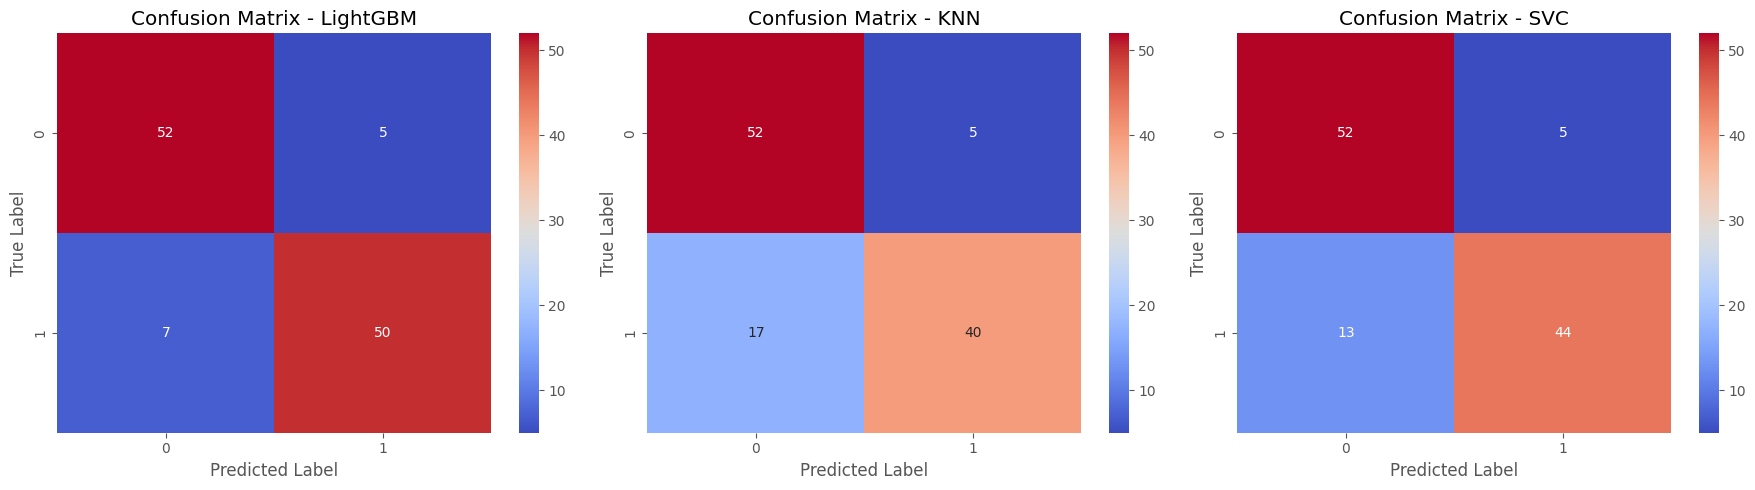

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = {'LightGBM': y_pred_lgbm, 'KNN': y_pred_knn, 'SVC': y_pred_svc}
for ax, (model_name, y_pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_test_balanced, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap="coolwarm", ax=ax)
    ax.set_title(f"Confusion Matrix - {model_name}")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
plt.tight_layout()
plt.show()

## Analysis of the confusion matrix results
LightGBM achieves the best performance, correctly classifying most of the cases and making the fewest errors for both healthy and diabetic patients (5 false positives and 7 false negatives).

KNN has a clearly higher proportion of false negatives (17), which means it more frequently classifies diabetic patients as healthy. This can be problematic in the context of diagnosis.

SVC performs better than KNN but worse than LightGBM—while it has fewer false negatives than KNN (13), it still has more than LightGBM

In [ ]:
results = {
    'LightGBM': {
        'accuracy': accuracy_score(y_test_balanced, y_pred_lgbm),
        'precision': precision_score(y_test_balanced, y_pred_lgbm),
        'recall': recall_score(y_test_balanced, y_pred_lgbm),
        'f1_score': f1_score(y_test_balanced, y_pred_lgbm),
        'roc_auc': roc_auc_score(y_test_balanced, final_lgbm.predict_proba(X_test_balanced)[:, 1])
    },
    'KNN': {
        'accuracy': accuracy_score(y_test_balanced, y_pred_knn),
        'precision': precision_score(y_test_balanced, y_pred_knn),
        'recall': recall_score(y_test_balanced, y_pred_knn),
        'f1_score': f1_score(y_test_balanced, y_pred_knn),
        'roc_auc': roc_auc_score(y_test_balanced, best_knn.predict_proba(X_test_scaled)[:, 1])
    },
    'SVC': {
        'accuracy': accuracy_score(y_test_balanced, y_pred_svc),
        'precision': precision_score(y_test_balanced, y_pred_svc),
        'recall': recall_score(y_test_balanced, y_pred_svc),
        'f1_score': f1_score(y_test_balanced, y_pred_svc),
        'roc_auc': roc_auc_score(y_test_balanced, best_svc.predict_proba(X_test_scaled)[:, 1])
    }
}

metrics_df = pd.DataFrame(results).T
print(tabulate(metrics_df, headers='keys', tablefmt='grid'))

+----------+------------+-------------+----------+------------+-----------+
|          |   accuracy |   precision |   recall |   f1_score |   roc_auc |
+==========+============+=============+==========+============+===========+
| LightGBM |   0.894737 |    0.909091 | 0.877193 |   0.892857 |  0.955371 |
+----------+------------+-------------+----------+------------+-----------+
| KNN      |   0.807018 |    0.888889 | 0.701754 |   0.784314 |  0.91582  |
+----------+------------+-------------+----------+------------+-----------+
| SVC      |   0.842105 |    0.897959 | 0.77193  |   0.830189 |  0.904278 |
+----------+------------+-------------+----------+------------+-----------+


## Wizualizacja wyników

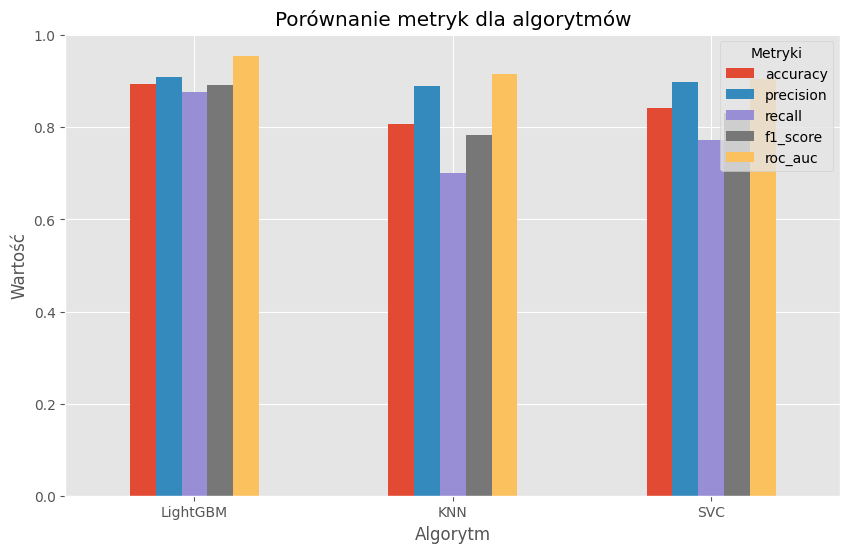

In [ ]:
metrics_df.plot(kind='bar', figsize=(10, 6))
plt.title("Porównanie metryk dla algorytmów")
plt.xlabel("Algorytm")
plt.ylabel("Wartość")
plt.xticks(rotation=0)
plt.legend(title="Metryki")
plt.show()

## **SUMMARY**
### Three classification algorithms were used: LightGBM, KNN, and SVC, each of which was optimally tuned using GridSearchCV, RandomizedSearchCV, and HalvingRandomSearchCV. The data were properly split into training and test sets, with the test set balanced to include an equal number of diabetic and non-diabetic patients. Feature scaling was applied, which was necessary for the KNN and SVC algorithms. The models’ performance was evaluated using classification metrics and visualized in the form of confusion matrices and a results table, allowing for a clear comparison of the classifiers’ effectiveness.